# Churn lable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("online retail cleaned.csv", parse_dates=['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max()

# Customer level features 
churn_df = df.groupby('Customer ID').agg(
    LastPurchase    = ('InvoiceDate',  'max'),
    Frequency       = ('Invoice',      'nunique'),
    Monetary        = ('Total Price',   'sum'),
    AvgOrderValue   = ('Total Price',   'mean'),
    TotalItems      = ('Quantity',     'sum'),
    UniqueProducts  = ('StockCode',    'nunique'),
    AvgQuantity     = ('Quantity',     'mean'),
    TotalOrders     = ('Invoice',      'nunique')
).reset_index()

# Recency calculate 
churn_df['Recency'] = (snapshot_date - churn_df['LastPurchase']).dt.days

# Churn label — 90 din se nahi aaya = churned
churn_df['Churned'] = (churn_df['Recency'] > 90).astype(int)

print(f"Total customers : {len(churn_df)}")
print(f"Churned         : {churn_df['Churned'].sum()} ({churn_df['Churned'].mean()*100:.1f}%)")
print(f"Active          : {(churn_df['Churned']==0).sum()} ({(churn_df['Churned']==0).mean()*100:.1f}%)")

Total customers : 4226
Churned         : 1407 (33.3%)
Active          : 2819 (66.7%)


# Feature and target saperate

In [4]:
features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
            'TotalItems', 'UniqueProducts', 'AvgQuantity']

X = churn_df[features]
y = churn_df['Churned']

# Train/Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size: (3380, 7)
Test size : (846, 7)


# model train

In [5]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'auc'    : auc
    }

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"AUC Score: {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['Active','Churned']))


Model: Logistic Regression
AUC Score: 1.0000
              precision    recall  f1-score   support

      Active       0.99      1.00      0.99       564
     Churned       1.00      0.98      0.99       282

    accuracy                           0.99       846
   macro avg       0.99      0.99      0.99       846
weighted avg       0.99      0.99      0.99       846


Model: Random Forest
AUC Score: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       564
     Churned       1.00      1.00      1.00       282

    accuracy                           1.00       846
   macro avg       1.00      1.00      1.00       846
weighted avg       1.00      1.00      1.00       846


Model: Gradient Boosting
AUC Score: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       564
     Churned       1.00      1.00      1.00       282

    accuracy                           1.00       84

# confusion metrics plot

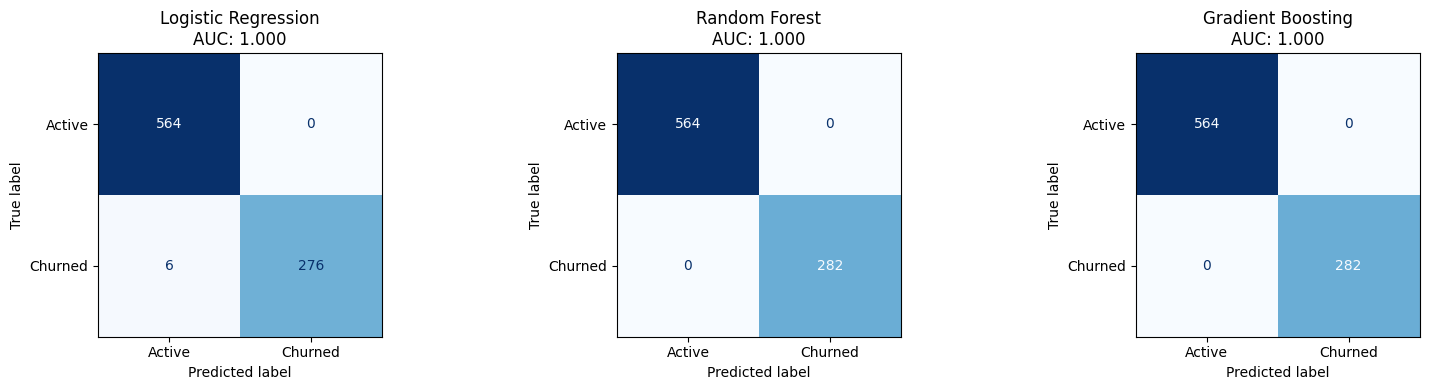

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Active','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAUC: {res['auc']:.3f}")

plt.tight_layout()
plt.savefig("plots/confusion_matrices.png")
plt.show()

# roc curv compare

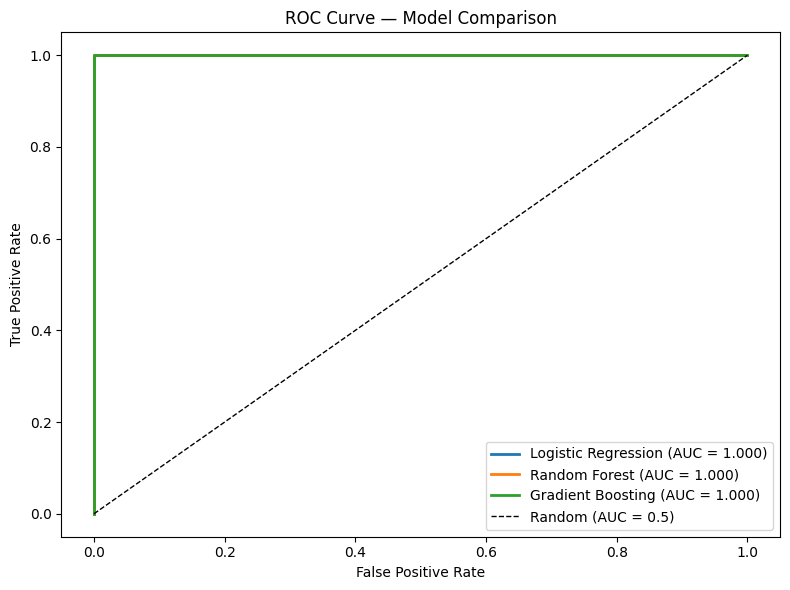

In [7]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {res['auc']:.3f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("plots/roc_curves.png")
plt.show()

# feature importance (random forest)

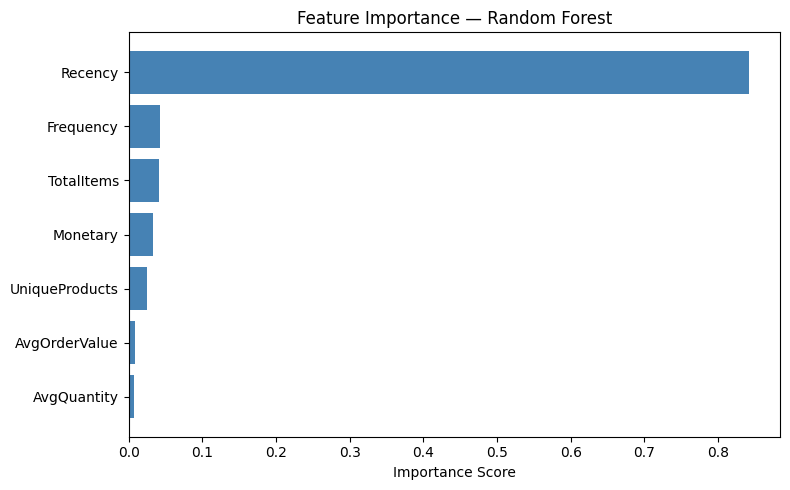

          Feature  Importance
0         Recency    0.842067
1       Frequency    0.042712
4      TotalItems    0.041906
2        Monetary    0.032703
5  UniqueProducts    0.024588
3   AvgOrderValue    0.009231
6     AvgQuantity    0.006793


In [8]:
rf_model = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plots/feature_importance.png")
plt.show()

print(importance_df.sort_values('Importance', ascending=False))

#  churn probanilty assign to every customer

In [9]:
# Best model use karo — usually Random Forest ya Gradient Boosting
best_model = results['Random Forest']['model']

# Poore dataset pe predict karo
X_all = scaler.transform(churn_df[features])
churn_df['Churn_Probability'] = best_model.predict_proba(X_all)[:, 1]
churn_df['Churn_Predicted']   = best_model.predict(X_all)

# Risk categories banao
def risk_category(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    elif prob >= 0.25:
        return 'Low Risk'
    else:
        return 'Safe'

churn_df['Risk_Category'] = churn_df['Churn_Probability'].apply(risk_category)

print(churn_df['Risk_Category'].value_counts())

Risk_Category
Safe         2819
High Risk    1407
Name: count, dtype: int64


# high risk customer find

In [11]:
# Top 20 high risk customers
high_risk = churn_df[churn_df['Risk_Category'] == 'High Risk'] \
            .sort_values('Monetary', ascending=False) \
            .head(20)

print("\nTop 20 High-Value Churning Customers:")
print(high_risk[['Customer ID', 'Recency', 'Frequency',
                  'Monetary', 'Churn_Probability']].to_string())


Top 20 High-Value Churning Customers:
      Customer ID  Recency  Frequency  Monetary  Churn_Probability
2402        15768      111         31  14646.26               0.99
3631        17448      132         46  14409.91               0.95
2397        15760      265          2  13916.34               0.99
369         12918      261          1  10953.50               0.97
25          12380      100          7   6669.97               0.98
254         12758       94          5   6038.93               0.97
2200        15480      100          4   5109.26               0.99
913         13680      106          8   4975.35               0.97
3466        17230      218          9   4725.16               0.99
397         12957      176          5   4602.55               0.99
1953        15125      114          9   4333.41               0.97
1763        14855      109          5   4178.65               0.99
464         13044      127         10   4141.66               0.98
112         12510      

In [12]:
churn_df.to_csv("churn_predictions.csv", index=False)

# Summary
print("\n===== CHURN SUMMARY =====")
print(f"Total Customers   : {len(churn_df)}")
print(f"High Risk         : {(churn_df['Risk_Category']=='High Risk').sum()}")
print(f"Medium Risk       : {(churn_df['Risk_Category']=='Medium Risk').sum()}")
print(f"Low Risk          : {(churn_df['Risk_Category']=='Low Risk').sum()}")
print(f"Safe              : {(churn_df['Risk_Category']=='Safe').sum()}")
print(f"\nBest Model AUC    : {max(r['auc'] for r in results.values()):.4f}")
print("Predictions saved to data/churn_predictions.csv")


===== CHURN SUMMARY =====
Total Customers   : 4226
High Risk         : 1407
Medium Risk       : 0
Low Risk          : 0
Safe              : 2819

Best Model AUC    : 1.0000
Predictions saved to data/churn_predictions.csv
